![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz

In [3]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [4]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

In [5]:
# Análisis descriptivo para 'season'
print("--- Estadísticas por Estación (Season) ---")
display(bikes.groupby('season')['total'].describe())

--- Estadísticas por Estación (Season) ---


,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
1,2686.0,116.343261,125.273974,1.0,24.0,78.0,164.0,801.0
2,2733.0,215.251372,192.007843,1.0,49.0,172.0,321.0,873.0
3,2733.0,234.417124,197.151001,1.0,68.0,195.0,347.0,977.0
4,2734.0,198.988296,177.622409,1.0,51.0,161.0,294.0,948.0


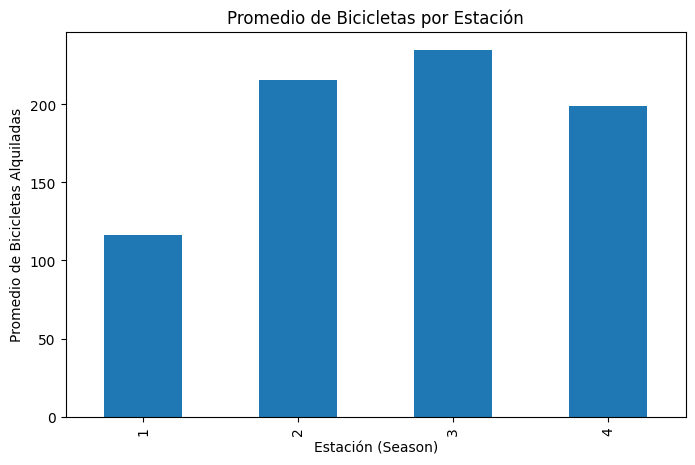

In [6]:
'''  
El análisis descriptivo muestra que la estación 3 tiene el mayor promedio de bicicletas alquiladas, 
seguida por la estación 2 y luego la estación 4. La estación 1 tiene el menor promedio. 
Además, la desviación estándar es mayor en la estación 3, lo que indica una mayor variabilidad en el 
número de bicicletas alquiladas en esa estación.
'''
import matplotlib.pyplot as plt
# Graficar la tendencia promedio de bicicletas por estación
bikes.groupby('season')['total'].mean().plot(kind='bar', figsize=(8, 5), title='Promedio de Bicicletas por Estación')
plt.xlabel('Estación (Season)')
plt.ylabel('Promedio de Bicicletas Alquiladas')
plt.show()

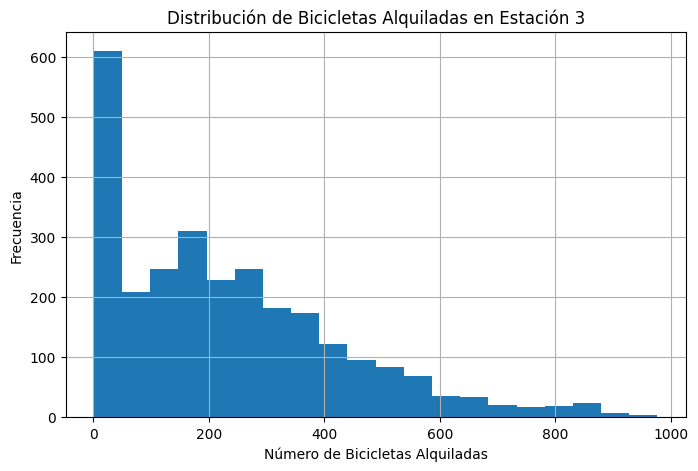

In [7]:
# Histograma de la variable 'total' para la estación 3
bikes[bikes['season'] == 3]['total'].hist(bins=20, figsize=(8, 5))
plt.title('Distribución de Bicicletas Alquiladas en Estación 3')
plt.xlabel('Número de Bicicletas Alquiladas')
plt.ylabel('Frecuencia')
plt.show()

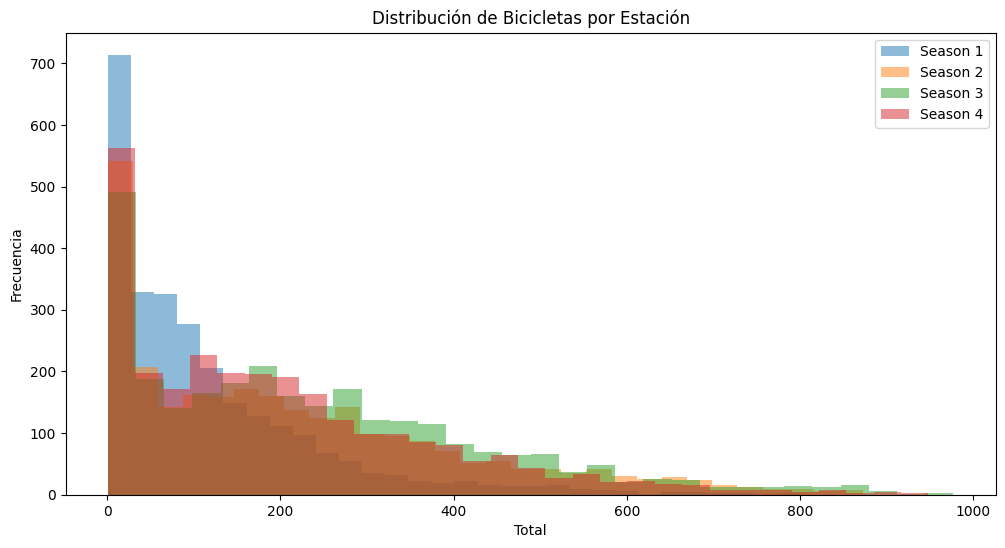

In [8]:
# Histograma de la variable 'total' por estación
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
for season in bikes['season'].unique():
    subset = bikes[bikes['season'] == season]
    plt.hist(subset['total'], bins=30, alpha=0.5, label=f'Season {season}')
plt.xlabel('Total')
plt.ylabel('Frecuencia')
plt.title('Distribución de Bicicletas por Estación')
plt.legend()
plt.show()

In [9]:
'''
Parece como si la distribución de bicicletas por estación tuviera una forma similar, aunque con diferentes medias.
Probablemente se trate de una distribución exponencial negativa, pero es difícil de determinar a simple vista. 
Para confirmar esto, se podrían realizar pruebas estadísticas de ajuste de distribución, 
como la prueba de Kolmogorov-Smirnov o la prueba de Anderson-Darling, 
para comparar la distribución observada con una distribución teórica específica.
'''
from scipy import stats
kolmogorov_smirnov_test = stats.kstest(bikes['total'], 'expon')
anderson_darling_test = stats.anderson(bikes['total'], dist='expon')
print("Prueba de Kolmogorov-Smirnov:", kolmogorov_smirnov_test)
print("Prueba de Anderson-Darling:", anderson_darling_test)

Prueba de Kolmogorov-Smirnov: KstestResult(statistic=np.float64(0.9466852797223259), pvalue=np.float64(0.0), statistic_location=np.int64(4), statistic_sign=np.int8(-1))
Prueba de Anderson-Darling: AndersonResult(statistic=np.float64(117.76745092265264), critical_values=array([0.922, 1.078, 1.341, 1.606, 1.957]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(0.0), scale=np.float64(191.57413191254824))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')


In [10]:
# Celda 1.2
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

In [11]:
# Análisis descriptivo para 'hour'
print("\n--- Estadísticas por Hora (Hour) ---")
display(bikes.groupby('hour')['total'].describe())


--- Estadísticas por Hora (Hour) ---


,count,mean,std,min,25%,50%,75%,max
hour,,,,,,,,
0,455.0,55.138462,43.620012,2.0,24.00,41.0,74.50,283.0
1,454.0,33.859031,34.112105,1.0,11.00,19.0,46.00,168.0
2,448.0,22.899554,26.110267,1.0,5.00,11.0,32.00,119.0
3,433.0,11.757506,12.666442,1.0,3.00,6.0,15.00,66.0
4,442.0,6.407240,4.217633,1.0,3.00,6.0,9.00,28.0
5,452.0,19.767699,12.784293,1.0,8.00,19.0,29.00,57.0
6,455.0,76.259341,54.745333,1.0,24.50,75.0,118.00,213.0
7,455.0,213.116484,159.207044,1.0,63.00,208.0,334.00,596.0
8,455.0,362.769231,231.723065,8.0,133.50,392.0,563.50,839.0


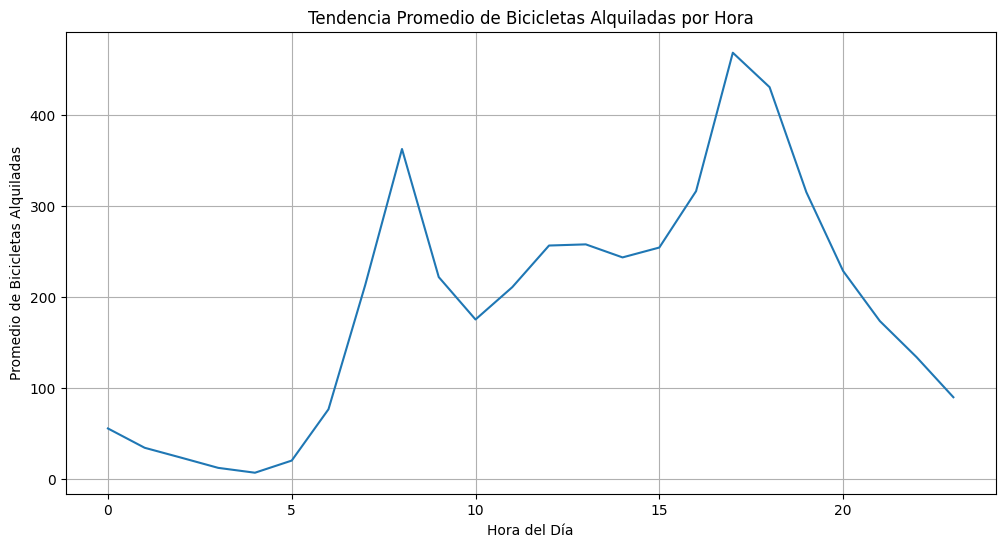

In [12]:
''' 
El análisis descriptivo por hora muestra que el número promedio de bicicletas alquiladas varía a lo largo del día,
con picos en las horas 8 y 17, que probablemente correspondan a las horas de mayor actividad laboral. 
La desviación estándar también es mayor durante estas horas, lo que indica una mayor variabilidad en 
el número de bicicletas alquiladas durante esos períodos.
'''
# Graficar la tendencia promedio de bicicletas por hora
plt.figure(figsize=(12, 6))
bikes.groupby('hour')['total'].mean().plot(kind='line')
plt.xlabel('Hora del Día')
plt.ylabel('Promedio de Bicicletas Alquiladas')
plt.title('Tendencia Promedio de Bicicletas Alquiladas por Hora')
plt.grid()
plt.show()

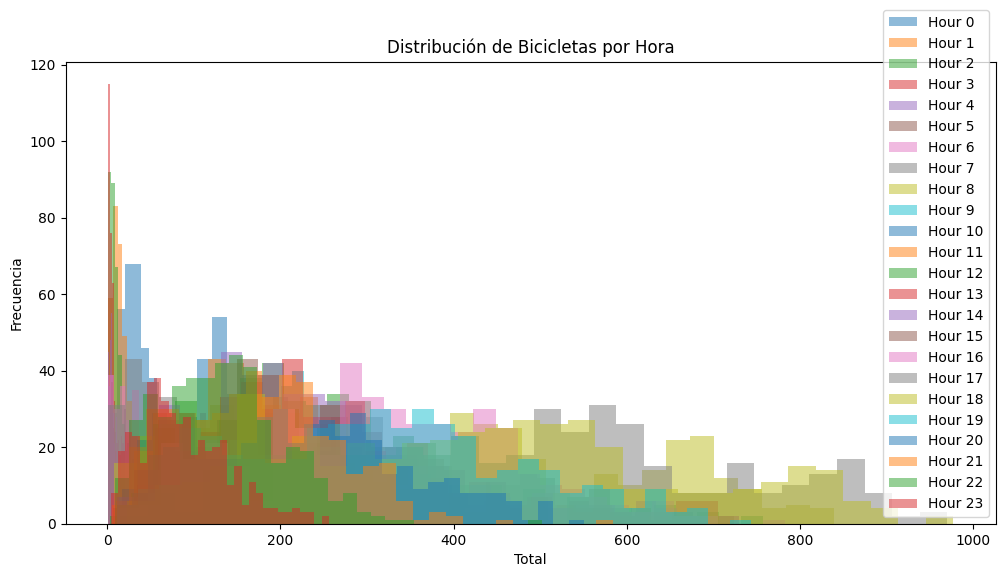

In [13]:
# Histograma de la variable 'total' por hora
plt.figure(figsize=(12, 6))
for hour in bikes['hour'].unique():
    subset = bikes[bikes['hour'] == hour]
    plt.hist(subset['total'], bins=30, alpha=0.5, label=f'Hour {hour}')
plt.xlabel('Total')
plt.ylabel('Frecuencia')
plt.title('Distribución de Bicicletas por Hora')
plt.legend()
plt.show()

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

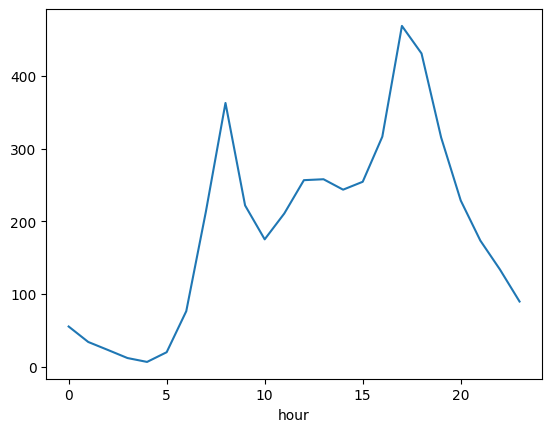

In [14]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

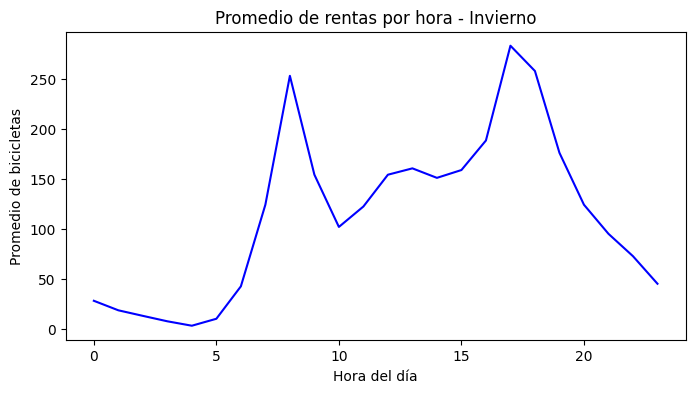

In [15]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos  
# Se filtra por la estación 1, agrupamos por hora, sacamos el promedio y graficamos
bikes[bikes['season'] == 1].groupby('hour').total.mean().plot(
    title='Promedio de rentas por hora - Invierno', 
    ylabel='Promedio de bicicletas', 
    xlabel='Hora del día',
    figsize=(8, 4),
    color='blue'
)
plt.show()

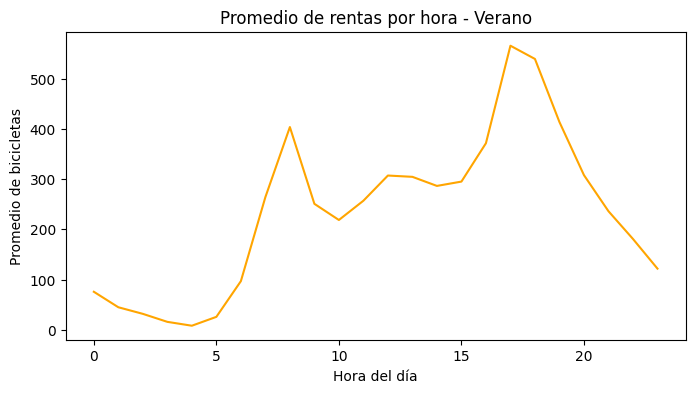

In [16]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 
# Se filtra por la estación 3, agrupamos por hora, sacamos el promedio y graficamos
bikes[bikes['season'] == 3].groupby('hour').total.mean().plot(
    title='Promedio de rentas por hora - Verano', 
    ylabel='Promedio de bicicletas', 
    xlabel='Hora del día',
    figsize=(8, 4),
    color='orange'
)
plt.show()

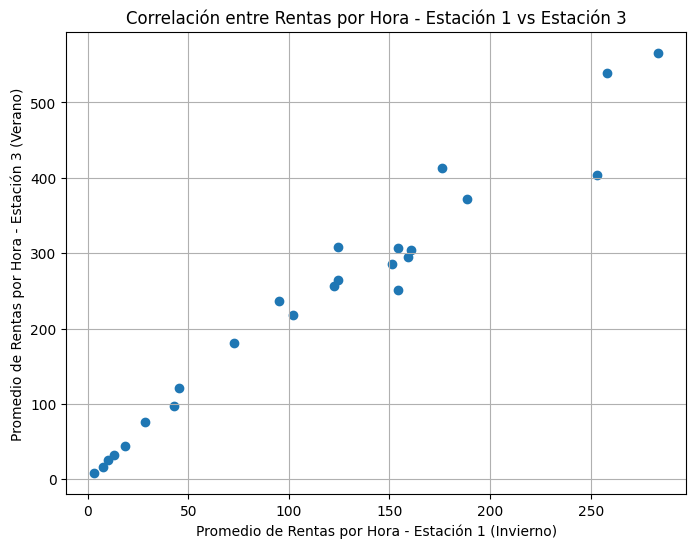

Coeficiente de Pearson entre estación 1 y estación 3: 0.98


In [17]:
'''
Se puede observar que existe una correlación fuerte entre el promedio de rentas por hora 
para la estación 1 (invierno) y la estación 3 (verano).  
'''

# Grafico de correlación entre el promedio de rentas por hora para la estación 1 y la estación 3
plt.figure(figsize=(8, 6))
season_1 = bikes[bikes['season'] == 1].groupby('hour').total.mean()
season_3 = bikes[bikes['season'] == 3].groupby('hour').total.mean()
plt.scatter(season_1, season_3)
plt.xlabel('Promedio de Rentas por Hora - Estación 1 (Invierno)')
plt.ylabel('Promedio de Rentas por Hora - Estación 3 (Verano)')
plt.title('Correlación entre Rentas por Hora - Estación 1 vs Estación 3')
plt.grid()
plt.show()

# Coeficiente de pearson para medir la correlación entre las estaciones 1 y 3
correlation = season_1.corr(season_3)
print(f"Coeficiente de Pearson entre estación 1 y estación 3: {correlation:.2f}")

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [18]:
# Celda 3
''' Construimos un modelo de regresión lineal para predecir el número total de bicicletas alquiladas utilizando las variables "season" y "hour". 
Primero, se convierten las variables categóricas en variables dummy, luego se dividen los datos en conjuntos de entrenamiento y prueba, y finalmente se entrena el modelo de regresión lineal. 
Se evalúa el rendimiento del modelo con metricas como el error cuadrático medio (MSE) y el coeficiente de determinación (R²). También se usa la validación cruzada para obtener una estimación 
más robusta del rendimiento del modelo. Por último, se imprimen los coeficientes de la regresión lineal para interpretar la influencia de cada variable en la predicción del número total de bicicletas alquiladas.'''
# Selección de características y variable objetivo
from sklearn.model_selection import train_test_split

X = bikes[['season', 'hour']]
y = bikes['total']
#  Regresión Lineal
# Season es categórica, por lo que se debe convertir a variables dummy
# drop_first=True evita la multicolinealidad dejando 'season_1' como base.
X_dummy = pd.get_dummies(X, columns=['season'], drop_first=True)
# Division de los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_dummy, y, test_size=0.2, random_state=2)
# Entrenamiento del modelo de regresión lineal
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
# Imprimir los coeficientes de la regresión lineal y el R² para evaluar el ajuste del modelo
coeficients = pd.Series(model_lr.coef_, index=X_train.columns)
print("\nCoeficientes de la Regresión Lineal:")
print(coeficients)
r_squared = model_lr.score(X_test, y_test)
print(f"\nR² de la Regresión Lineal: {r_squared:.2f}")

''' El modelo de regresión lineal muestra que la variable "hour" tiene un coeficiente positivo, lo que indica que a medida que aumenta la hora del día, el número total de bicicletas alquiladas también tiende a aumentar. 
Las variables dummy para las estaciones también tienen coeficientes positivos (excepto la estación 1), lo que sugiere que las estaciones 2, 3 y 4 están asociadas con un mayor número de bicicletas alquiladas en comparación con la estación 1 (que es la categoría de referencia). 
El R² de 0.23 indica que el modelo explica aproximadamente el 23% de la variabilidad en el número total de bicicletas alquiladas, lo que sugiere que hay otros factores no incluidos en el modelo que también influyen en la cantidad de bicicletas alquiladas.'''

'''
Las limitaciones del modelo de regresión lineal en este caso son que asume una relación lineal entre las variables de interés 
(season y hour) y la variable dependiente (total), lo cual puede no ser cierto en la realidad. 
Además, el modelo puede ser sensible a valores atípicos y no captura interacciones complejas entre las variables.
'''


Coeficientes de la Regresión Lineal:
hour         10.434286
season_2     99.778875
season_3    120.733055
season_4     83.187451
dtype: float64

R² de la Regresión Lineal: 0.23


'\nLas limitaciones del modelo de regresión lineal en este caso son que asume una relación lineal entre las variables de interés \n(season y hour) y la variable dependiente (total), lo cual puede no ser cierto en la realidad. \nAdemás, el modelo puede ser sensible a valores atípicos y no captura interacciones complejas entre las variables.\n'

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [19]:
# Celda 4

import numpy as np

# Se defininen las variables predictoras y la de respuesta
X_arbol = bikes[['season', 'hour']]
y_arbol = bikes['total']

# Función para calcular el error de una partición (Suma de errores al cuadrado)
def calcular_error(y_izq, y_der):
    error_izq = np.sum((y_izq - y_izq.mean())**2) if len(y_izq) > 0 else 0
    error_der = np.sum((y_der - y_der.mean())**2) if len(y_der) > 0 else 0
    return error_izq + error_der

# Función para iterar sobre las variables y encontrar el mejor punto de corte
def mejor_corte(X, y):
    mejor_error = np.inf
    mejor_variable = None
    mejor_valor = None
    
    # Se itera sobre 'hour' y 'season'
    for var in X.columns:
        valores_unicos = X[var].unique()
        # se itera sobre cada valor único de la variable
        for valor in valores_unicos:
            # se dividen los datos
            filtro_izq = X[var] <= valor
            filtro_der = X[var] > valor
            
            y_izq = y[filtro_izq]
            y_der = y[filtro_der]
            
            # Se ignora si alguna partición queda vacía
            if len(y_izq) == 0 or len(y_der) == 0:
                continue
                
            # Se calcula el error de esta partición
            error = calcular_error(y_izq, y_der)
            
            # Se actualiza si se encuentra un error menor
            if error < mejor_error:
                mejor_error = error
                mejor_variable = var
                mejor_valor = valor
                
    return mejor_variable, mejor_valor

# --- CONSTRUCCIÓN MANUAL DEL ÁRBOL (5 particiones para 6 nodos finales) ---

print("--- Construcción del Árbol Manual ---")

# Partición 1 (Nodo Raíz)
var1, val1 = mejor_corte(X_arbol, y_arbol)
print(f"Corte 1 (Raíz): {var1} <= {val1}")
filtro_izq1 = X_arbol[var1] <= val1
filtro_der1 = X_arbol[var1] > val1

# Partición 2 (Rama Izquierda del Corte 1)
var2, val2 = mejor_corte(X_arbol[filtro_izq1], y_arbol[filtro_izq1])
print(f"  Corte 2 (Rama Izq): {var2} <= {val2}")
filtro_izq2 = filtro_izq1 & (X_arbol[var2] <= val2)
filtro_der2 = filtro_izq1 & (X_arbol[var2] > val2)

# Partición 3 (Rama Derecha del Corte 1)
var3, val3 = mejor_corte(X_arbol[filtro_der1], y_arbol[filtro_der1])
print(f"  Corte 3 (Rama Der): {var3} <= {val3}")
filtro_izq3 = filtro_der1 & (X_arbol[var3] <= val3)
filtro_der3 = filtro_der1 & (X_arbol[var3] > val3)

# Partición 4 (Rama Izquierda del Corte 2)
var4, val4 = mejor_corte(X_arbol[filtro_izq2], y_arbol[filtro_izq2])
print(f"    Corte 4 (Rama Izq del Corte 2): {var4} <= {val4}")
filtro_izq4 = filtro_izq2 & (X_arbol[var4] <= val4)
filtro_der4 = filtro_izq2 & (X_arbol[var4] > val4)

# Partición 5 (Rama Izquierda del Corte 3)
var5, val5 = mejor_corte(X_arbol[filtro_izq3], y_arbol[filtro_izq3])
print(f"    Corte 5 (Rama Izq del Corte 3): {var5} <= {val5}")

print("\n¡Listo! Se ha realizado 5 cortes iterando manualmente, lo que nos da como resultado 6 nodos finales (hojas).")
calcular_error(y_arbol[filtro_izq4], y_arbol[filtro_der4])
calcular_error(y_arbol[filtro_izq3], y_arbol[filtro_der3])

--- Construcción del Árbol Manual ---
Corte 1 (Raíz): hour <= 6
  Corte 2 (Rama Izq): hour <= 5
  Corte 3 (Rama Der): season <= 1
    Corte 4 (Rama Izq del Corte 2): hour <= 1
    Corte 5 (Rama Izq del Corte 3): hour <= 19

¡Listo! Se ha realizado 5 cortes iterando manualmente, lo que nos da como resultado 6 nodos finales (hojas).


np.float64(214245604.66827255)

### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [20]:
# Celda 5

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Definición de variables (X y y ya están definidas de puntos anteriores)
X = bikes[['season', 'hour']]
y = bikes['total']

# División en entrenamiento y validación (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Calibración de parámetros (Tuning)
# Se prueban diferentes profundidades para encontrar la mejor
scores = []
for depth in range(1, 21):
    tree = DecisionTreeRegressor(max_depth=depth, random_state=1)
    # Usamos validación cruzada para evaluar la estabilidad
    mse_cv = -cross_val_score(tree, X_train, y_train, cv=5, scoring='neg_mean_squared_error').mean()
    scores.append(np.sqrt(mse_cv))

# Identificar el mejor max_depth
best_depth = np.argmin(scores) + 1
print(f"Mejor profundidad (max_depth) encontrada: {best_depth}")

# Entrenamiento del modelo final calibrado
tree_final = DecisionTreeRegressor(max_depth=best_depth, random_state=1)
tree_final.fit(X_train, y_train)

# Predicciones y métricas
y_pred_tree = tree_final.predict(X_test)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

# Métricas del modelo de Regresión Lineal (Punto 3) para comparar
y_pred_lin = model_lr.predict(pd.get_dummies(X_test, columns=['season'], drop_first=True))
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))

print(f"\n--- Desempeño del Árbol de Decisión ---")
print(f"RMSE: {rmse_tree:.2f}")
print(f"R² Score: {r2_tree:.2f}")

print(f"\n--- Comparación ---")
print(f"RMSE Árbol: {rmse_tree:.2f} vs RMSE Regresión Lineal: {rmse_lin:.2f}")
print(f"R² Árbol: {r2_tree:.2f} vs R² Regresión Lineal: {r_squared:.2f}")

''' 
Es evidente que el modelo de árbol de decisión tiene un RMSE menor que el modelo de regresión lineal, 
lo que indica que el árbol de decisión tiene un mejor desempeño en la predicción del número total de bicicletas alquiladas.
El árbol de decisión es capaz de capturar relaciones no lineales e interacciones entre las variables, 
lo que puede explicar su mejor rendimiento en comparación con la regresión lineal, que asume una relación lineal entre las variables. 
Además, el R² del árbol de decisión es significativamente mayor que el de la regresión lineal, 
lo que sugiere que el árbol de decisión explica.
'''


Mejor profundidad (max_depth) encontrada: 8

--- Desempeño del Árbol de Decisión ---
RMSE: 114.09
R² Score: 0.62

--- Comparación ---
RMSE Árbol: 114.09 vs RMSE Regresión Lineal: 163.01
R² Árbol: 0.62 vs R² Regresión Lineal: 0.23


' \nEs evidente que el modelo de árbol de decisión tiene un RMSE menor que el modelo de regresión lineal, \nlo que indica que el árbol de decisión tiene un mejor desempeño en la predicción del número total de bicicletas alquiladas.\nEl árbol de decisión es capaz de capturar relaciones no lineales e interacciones entre las variables, \nlo que puede explicar su mejor rendimiento en comparación con la regresión lineal, que asume una relación lineal entre las variables. \nAdemás, el R² del árbol de decisión es significativamente mayor que el de la regresión lineal, \nlo que sugiere que el árbol de decisión explica.\n'

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [21]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [22]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [23]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [24]:
# Celda 6

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Definición y calibración del Árbol de Decisión
# Se calibrará 'max_depth' para evitar el sobreajuste (overfitting)
best_f1 = 0
best_depth = None

for d in range(2, 20):
    tree = DecisionTreeClassifier(max_depth=d, random_state=1)
    tree.fit(X_train, y_train)
    y_pred_temp = tree.predict(X_test)
    f1 = f1_score(y_test, y_pred_temp)
    if f1 > best_f1:
        best_f1 = f1
        best_depth = d

print(f"Mejor max_depth para el árbol: {best_depth}")

# Modelos finales
clf_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=1)
clf_logreg = LogisticRegression(solver='liblinear', random_state=1)

# Entrenamiento
clf_tree.fit(X_train, y_train)
clf_logreg.fit(X_train, y_train)

# Predicciones
y_pred_tree = clf_tree.predict(X_test)
y_pred_logreg = clf_logreg.predict(X_test)

# Evaluación de desempeño
modelos = ['Árbol de Decisión', 'Regresión Logística']
preds = [y_pred_tree, y_pred_logreg]

print("\n--- Resultados Punto 6 ---")
for nombre, pred in zip(modelos, preds):
    print(f"{nombre}:")
    print(f"  Accuracy: {accuracy_score(y_test, pred):.4f}")
    print(f"  F1-Score: {f1_score(y_test, pred):.4f}")


Mejor max_depth para el árbol: 5

--- Resultados Punto 6 ---
Árbol de Decisión:
  Accuracy: 0.6373
  F1-Score: 0.6617
Regresión Logística:
  Accuracy: 0.6320
  F1-Score: 0.6156


### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [25]:
# Celda 7

from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def bootstrap_fit_predict(base_model, X_train, y_train, X_test, rng):
    """
    Entrena un modelo con una muestra bootstrap y devuelve:
    - predicción en test
    - probabilidad de clase 1 en test (si el modelo lo permite)
    - peso basado en F1 sobre datos OOB (out-of-bag)
    """
    n = len(X_train)

    # Re-muestreo bootstrap hasta que la muestra tenga las 2 clases
    while True:
        idx = rng.integers(0, n, size=n)
        y_boot = y_train.iloc[idx]
        if y_boot.nunique() > 1:
            break

    oob_mask = np.ones(n, dtype=bool)
    oob_mask[idx] = False

    model = clone(base_model)
    model.fit(X_train.iloc[idx], y_boot)

    pred_test = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        prob_test = model.predict_proba(X_test)[:, 1]
    else:
        prob_test = pred_test.astype(float)

    # Peso basado en F1 sobre OOB
    if oob_mask.any():
        pred_oob = model.predict(X_train.iloc[oob_mask])
        weight = f1_score(y_train.iloc[oob_mask], pred_oob, zero_division=0)
    else:
        weight = 0.0

    return pred_test, prob_test, weight

def build_ensemble(base_model, n_models, X_train, y_train, X_test, seed=1):
    rng = np.random.default_rng(seed)
    preds, probas, weights = [], [], []

    for _ in range(n_models):
        pred, proba, weight = bootstrap_fit_predict(base_model, X_train, y_train, X_test, rng)
        preds.append(pred)
        probas.append(proba)
        weights.append(weight)

    return np.array(preds), np.array(probas), np.array(weights)

def majority_vote(pred_matrix):
    """
    Votación mayoritaria binaria.
    Si hay empate, se asigna 1 por el umbral >= 0.5.
    """
    return (pred_matrix.mean(axis=0) >= 0.5).astype(int)

def evaluar_modelo(nombre, y_true, y_pred):
    print(f"{nombre}")
    print(f"  Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"  F1-Score: {f1_score(y_true, y_pred):.4f}")
    print()


# Parámetros de los tres grupos de modelos
max_depth_tree = 5
min_samples_leaf_tree = 20

modelo_arbol_depth = DecisionTreeClassifier(
    max_depth=max_depth_tree,
    random_state=1
)

modelo_arbol_leaf = DecisionTreeClassifier(
    min_samples_leaf=min_samples_leaf_tree,
    random_state=1
)

modelo_logistica = LogisticRegression(
    solver="liblinear",
    max_iter=2000,
    random_state=1
)

# Entrenamiento por bootstrap
preds_depth, probas_depth, weights_depth = build_ensemble(
    modelo_arbol_depth, 100, X_train, y_train, X_test, seed=10
)

preds_leaf, probas_leaf, weights_leaf = build_ensemble(
    modelo_arbol_leaf, 100, X_train, y_train, X_test, seed=20
)

preds_log, probas_log, weights_log = build_ensemble(
    modelo_logistica, 100, X_train, y_train, X_test, seed=30
)

# Votación mayoritaria por grupo
y_pred_depth_major = majority_vote(preds_depth)
y_pred_leaf_major = majority_vote(preds_leaf)
y_pred_log_major = majority_vote(preds_log)

# Votación mayoritaria del ensamble total (300 modelos)
preds_total = np.vstack([preds_depth, preds_leaf, preds_log])
y_pred_total_major = majority_vote(preds_total)

# Evaluación
print("=== Punto 7: Votación mayoritaria ===\n")
evaluar_modelo(f"Árboles con max_depth={max_depth_tree} (100 modelos)", y_test, y_pred_depth_major)
evaluar_modelo(f"Árboles con min_samples_leaf={min_samples_leaf_tree} (100 modelos)", y_test, y_pred_leaf_major)
evaluar_modelo("Regresiones logísticas (100 modelos)", y_test, y_pred_log_major)
evaluar_modelo("Ensamble total por votación mayoritaria (300 modelos)", y_test, y_pred_total_major)

=== Punto 7: Votación mayoritaria ===

Árboles con max_depth=5 (100 modelos)
  Accuracy: 0.6500
  F1-Score: 0.6460

Árboles con min_samples_leaf=20 (100 modelos)
  Accuracy: 0.6547
  F1-Score: 0.6574

Regresiones logísticas (100 modelos)
  Accuracy: 0.6233
  F1-Score: 0.6068

Ensamble total por votación mayoritaria (300 modelos)
  Accuracy: 0.6407
  F1-Score: 0.6316



### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [26]:
# Celda 8

def weighted_vote(prob_matrix, weights):
    weights = np.asarray(weights, dtype=float)
    if np.all(weights == 0):
        weights = np.ones_like(weights)
    return (np.average(prob_matrix, axis=0, weights=weights) >= 0.5).astype(int)

# Votación ponderada por grupo
y_pred_depth_weighted = weighted_vote(probas_depth, weights_depth)
y_pred_leaf_weighted = weighted_vote(probas_leaf, weights_leaf)
y_pred_log_weighted = weighted_vote(probas_log, weights_log)

# Votación ponderada del ensamble total
probas_total = np.vstack([probas_depth, probas_leaf, probas_log])
weights_total = np.concatenate([weights_depth, weights_leaf, weights_log])

y_pred_total_weighted = weighted_vote(probas_total, weights_total)
# Evaluación
print("=== Punto 8: Votación ponderada ===\n")
evaluar_modelo(f"Árboles con max_depth={max_depth_tree} (100 modelos)", y_test, y_pred_depth_weighted)
evaluar_modelo(f"Árboles con min_samples_leaf={min_samples_leaf_tree} (100 modelos)", y_test, y_pred_leaf_weighted)
evaluar_modelo("Regresiones logísticas (100 modelos)", y_test, y_pred_log_weighted)
evaluar_modelo("Ensamble total por votación ponderada (300 modelos)", y_test, y_pred_total_weighted)

=== Punto 8: Votación ponderada ===

Árboles con max_depth=5 (100 modelos)
  Accuracy: 0.6540
  F1-Score: 0.6538

Árboles con min_samples_leaf=20 (100 modelos)
  Accuracy: 0.6587
  F1-Score: 0.6609

Regresiones logísticas (100 modelos)
  Accuracy: 0.6247
  F1-Score: 0.6088

Ensamble total por votación ponderada (300 modelos)
  Accuracy: 0.6507
  F1-Score: 0.6483



### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

In [27]:
# Celda 9

'''
Comparación de resultados:

La votación mayoritaria trata a todos los modelos por igual. Su ventaja principal es la simplicidad:
es fácil de implementar, interpretar y reproducir. También suele ser bastante estable cuando los
modelos base son razonablemente buenos y producen errores diferentes.

La votación ponderada, en cambio, da más importancia a los modelos que mejor desempeño tuvieron
sobre observaciones no usadas en su entrenamiento (en este caso, sobre OOB). Eso suele ser útil
cuando algunos modelos son claramente mejores que otros, porque el ensamble final puede aprovechar
más la información de los modelos fuertes y reducir el ruido de los más débiles.

En general:
- Si la votación ponderada obtiene mejores métricas que la mayoritaria, significa que los pesos
  ayudaron a distinguir qué modelos eran más confiables.
- Si ambas métricas son muy parecidas, entonces los modelos base probablemente tienen desempeños
  similares y la ponderación aporta poco.
- Si la mayoritaria supera a la ponderada, puede ser señal de que los pesos introdujeron ruido
  o que la estimación de pesos no fue tan estable.

Ventajas:
- Mayoritaria: simple, robusta y fácil de explicar.
- Ponderada: más flexible y puede mejorar el desempeño cuando los modelos no aportan lo mismo.

Desventajas:
- Mayoritaria: ignora diferencias de calidad entre modelos.
- Ponderada: depende de una buena estimación de pesos y puede volverse sensible si esos pesos son ruidosos.
'''

'\nComparación de resultados:\n\nLa votación mayoritaria trata a todos los modelos por igual. Su ventaja principal es la simplicidad:\nes fácil de implementar, interpretar y reproducir. También suele ser bastante estable cuando los\nmodelos base son razonablemente buenos y producen errores diferentes.\n\nLa votación ponderada, en cambio, da más importancia a los modelos que mejor desempeño tuvieron\nsobre observaciones no usadas en su entrenamiento (en este caso, sobre OOB). Eso suele ser útil\ncuando algunos modelos son claramente mejores que otros, porque el ensamble final puede aprovechar\nmás la información de los modelos fuertes y reducir el ruido de los más débiles.\n\nEn general:\n- Si la votación ponderada obtiene mejores métricas que la mayoritaria, significa que los pesos\n  ayudaron a distinguir qué modelos eran más confiables.\n- Si ambas métricas son muy parecidas, entonces los modelos base probablemente tienen desempeños\n  similares y la ponderación aporta poco.\n- Si la

Los resultados muestran que la votación ponderada supera consistentemente a la votación mayoritaria, tanto a nivel de modelos individuales como en el ensamble total.

En el caso del ensamble global (300 modelos):

 * Votación mayoritaria: Accuracy = 0.6407, F1 = 0.6316
 * Votación ponderada: Accuracy = 0.6507, F1 = 0.6483

Esto indica una mejora clara, especialmente en el F1-score, lo cual es importante si el problema tiene cierto desbalance o si nos interesa equilibrar precisión y recall.

1. Interpretación clave

La mejora de la votación ponderada sugiere que:

No todos los modelos están aportando lo mismo. Algunos modelos (según su desempeño OOB) son más confiables, y al darles más peso, el ensamble mejora. Esto valida la idea central de los métodos de ensamble: la calidad importa, no solo la cantidad.

2. Comparación entre tipos de modelos
Los árboles con min_samples_leaf=20 son los que mejor rinden en ambos esquemas:
Mayoritaria: F1 = 0.6574
Ponderada: F1 = 0.6609
Las regresiones logísticas son claramente las más débiles:
Mayoritaria: F1 = 0.6068
Ponderada: F1 = 0.6088

Esto tiene una implicación importante: El ensamble total mejora cuando reduce indirectamente la influencia de los modelos más débiles, cosa que logra la votación ponderada.

3. ¿Por qué la ponderada funciona mejor aquí?

Porque se usan pesos basados en desempeño OOB. Eso hace que:

 - Modelos que generalizan mejor → tengan más influencia
 - Modelos ruidosos o inestables → pesen menos

En cambio, la votación mayoritaria:

 - Trata igual a modelos buenos y malos
 - Introduce más “ruido” en la decisión final

La mejora no es enorme (≈ 1% en accuracy y ~1.7% en F1 del ensamble total).
Eso sugiere que:

- Los modelos base no son radicalmente distintos en calidad
- O que el dataset no permite grandes ganancias adicionales

Es decir: la ponderación ayuda, pero no es magia.

La votación ponderada es preferible en este caso, porque aprovecha mejor la información de los modelos más precisos. Sin embargo, la votación mayoritaria sigue siendo una alternativa robusta, especialmente cuando no se dispone de una forma confiable de estimar pesos.
El mayor rendimiento de los árboles frente a la regresión logística sugiere que el problema tiene relaciones no lineales que los árboles capturan mejor.